In [1]:
# This notebook demonstrates a simple ML pipeline for tumor vs normal classification using gene expression data (GSE68848).

In [2]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
# Loading the data and inspecting first 5 rows
data = pd.read_csv("../data/GSE68848_series_matrix.txt", sep="\t", comment="!")
data.head()

,ID_REF,GSM1683515,GSM1683516,GSM1683517,GSM1683518,GSM1683519,GSM1683520,GSM1683521,GSM1683522,GSM1683523,...,GSM1684085,GSM1684086,GSM1684087,GSM1684088,GSM1684089,GSM1684090,GSM1684091,GSM1684092,GSM1684093,GSM1684094
0,1007_s_at,4813.090,3136.610,2507.840,12800.1000,3031.9000,9044.1400,10821.0000,15361.600,13088.9000,...,8089.1700,7669.5200,12855.0000,8206.6100,5972.780,10626.100,4735.020,10148.3000,8358.7800,6882.5300
1,1053_at,349.121,353.851,297.220,742.1620,586.9810,382.4880,676.0310,651.333,319.7870,...,421.5320,501.5610,553.0030,810.4970,313.950,435.037,347.881,417.6960,518.3480,1087.3100
2,117_at,569.912,247.192,194.061,467.8430,740.6210,686.4390,394.2430,265.994,286.8720,...,344.2870,2199.7200,492.8440,426.5180,491.768,229.774,287.875,314.4720,344.8450,468.5740
3,121_at,1199.500,1662.230,1046.150,1243.4700,1416.4000,1577.2500,1264.7600,1941.030,1455.2300,...,1219.6900,1370.1000,1436.9600,2373.5300,1265.070,1502.070,1527.190,1671.0300,1722.7400,1513.9100
4,1255_g_at,101.771,217.155,125.293,76.1933,75.3743,44.9102,39.7982,104.764,13.8261,...,85.8655,40.9557,71.4984,96.8979,55.067,41.438,204.821,40.1318,91.2356,69.6433


In [4]:
# Setting gene names as index
data = data.set_index("ID_REF")
# Transposing so that each row is a sample
data = data.T

In [5]:
data.head()

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM1683515,4813.09,349.121,569.912,1199.50,101.7710,509.316,257.776,22.2615,249.09100,252.345,...,8259.67,6046.88,26055.0,19383.1,13.6404,38.7198,8.33072,3.09115,11.1494,6.15083
GSM1683516,3136.61,353.851,247.192,1662.23,217.1550,325.850,326.504,53.6479,7.05469,227.808,...,3803.10,3001.44,15816.6,10292.9,15.9207,7.7951,10.34290,3.01301,23.3282,14.94460
GSM1683517,2507.84,297.220,194.061,1046.15,125.2930,212.916,239.018,32.8535,12.96080,367.226,...,7150.03,6671.15,20880.7,17006.3,14.8842,44.8222,7.30131,4.13685,16.2188,14.43200
GSM1683518,12800.10,742.162,467.843,1243.47,76.1933,828.812,194.959,71.7985,144.89100,197.115,...,11914.50,7731.51,41753.9,36719.8,37.2806,18.7116,10.33440,4.98580,71.9908,10.54700
GSM1683519,3031.90,586.981,740.621,1416.40,75.3743,366.434,342.647,66.4799,105.14600,139.915,...,11644.20,9340.55,34583.8,24872.4,21.8861,19.0290,5.82728,3.53525,86.2422,15.32830


In [ ]:
# Inspecting metadata (output removed for brevity)
with open("../data/GSE68848_series_matrix.txt", "r") as f:
    for i in range(50):
        print(f.readline())

In [7]:
# Extracting sample labels from the GEO metadata
labels = []
with open("../data/GSE68848_series_matrix.txt", "r") as f:
    for line in f:
        if "Sample_characteristics_ch1" in line:
            labels = line.strip().split("\t")[1:]
            break
labels[:15]

['"disease state: GBM"',
 '"disease state: NON_TUMOR"',
 '"disease state: ASTROCYTOMA"',
 '"disease state: GBM"',
 '"disease state: GBM"',
 '"disease state: ASTROCYTOMA"',
 '"disease state: GBM"',
 '"disease state: ASTROCYTOMA"',
 '"disease state: ASTROCYTOMA"',
 '"disease state: GBM"',
 '"disease state: UNKNOWN"',
 '"disease state: MIXED"',
 '"disease state: NON_TUMOR"',
 '"disease state: GBM"',
 '"disease state: OLIGODENDROGLIOMA"']

In [8]:
# Cleaning labels
labels = [l.replace('"', '').split(": ")[-1] for l in labels]
labels[:10]

['GBM',
 'NON_TUMOR',
 'ASTROCYTOMA',
 'GBM',
 'GBM',
 'ASTROCYTOMA',
 'GBM',
 'ASTROCYTOMA',
 'ASTROCYTOMA',
 'GBM']

In [9]:
# Converting to binary classification problem
labels_binary = ["normal" if l == "NON_TUMOR" else "tumor" for l in labels]

In [10]:
# Checking class distribution
Counter(labels_binary)

Counter({'tumor': 552, 'normal': 28})

In [11]:
# Attaching labels to dataset
data["label"] = labels_binary 

In [12]:
# Encoding labels numerically for ML training
le = LabelEncoder()
data["label"] = le.fit_transform(data["label"])

In [13]:
# Splitting the data for ML training
X_raw = data.drop("label", axis=1)
y = data["label"]
# Using stratified split to preserve class distribution as data is imbalanced
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# Feature selection
selector = VarianceThreshold(threshold=0.5)
# Feature selection is fitted only on training data to prevent data leakage
X_train = selector.fit_transform(X_train)
X_test = selector.transform(X_test)

In [15]:
# Training a LogisticRegression
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)
print("Logistic Regression model trained")

Logistic Regression model trained


In [16]:
# Training a RandomForest model
rf = RandomForestClassifier(class_weight="balanced")
rf.fit(X_train, y_train)
print("Random Forest model trained")

Random Forest model trained


In [17]:
# evaluating the models trained
pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, pred_lr))
print("RF Accuracy:", accuracy_score(y_test, pred_rf))
print("\nRF Classification Report:\n")
print(classification_report(y_test, pred_rf))

LR Accuracy: 0.9741379310344828
RF Accuracy: 0.9741379310344828

RF Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.97      1.00      0.99       110

    accuracy                           0.97       116
   macro avg       0.99      0.75      0.83       116
weighted avg       0.97      0.97      0.97       116



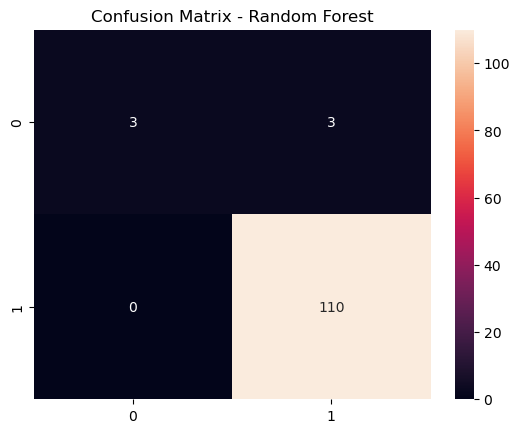

In [18]:
cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

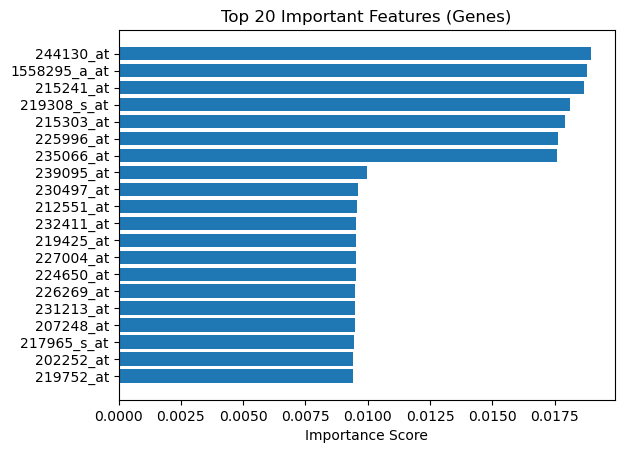

In [19]:
# Inspecting feature importances for interpretation; what genes contribute the most to classification
importances = rf.feature_importances_
indices = np.argsort(importances)[-20:]
feature_names = X_raw.columns[selector.get_support()]
top_genes = feature_names[indices]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Top 20 Important Features (Genes)")
plt.xlabel("Importance Score")
plt.yticks(range(len(indices)), top_genes)
plt.show()

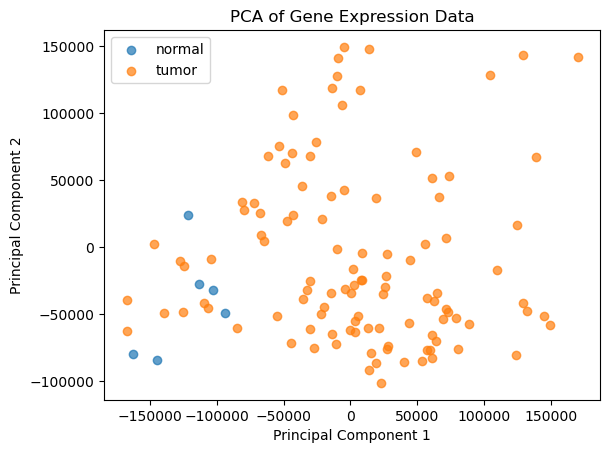

In [20]:
# Using PCA to reduce high-dimensional gene expression data into 2 components for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
# Plotting tumor vs normal; visualizing how well they separate in low-dimensional space
for label, color in zip([0, 1], ["blue", "red"]):
    plt.scatter(
        X_test_pca[y_test == label, 0],
        X_test_pca[y_test == label, 1],
        label="normal" if label == 0 else "tumor",
        alpha=0.7
    )
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Gene Expression Data")
plt.legend()
plt.show()